## Statistics Project : Credit card launch for Atliqo bank
## Name: Aadith P
## Roll No:CB.AI.P2DSC25001

In [ ]:
import pandas as pd


In [ ]:
df_cust=pd.read_csv('customers.csv')
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Dhruv Bansal,Female,2,City,Business Owner,358211.0,Married
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married
3,4,Sara Dwivedi,Male,24,Rural,Freelancer,33563.0,Married
4,5,Aarohi Negi,Male,48,City,Consultant,39406.0,Married


In [ ]:
df_cs=pd.read_csv("credit_profiles.csv")
df_cs.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
0,1,749,0.585171,19571.0,0.0,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0
2,3,544,0.854807,513.0,4.0,1000.0
3,4,504,0.336938,224.0,2.0,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0


In [ ]:
df_trans=pd.read_csv("transactions.csv")
df_trans.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking


#### Data Authenticity check

In [ ]:
df_cust.isnull().sum()

,0
cust_id,0
name,0
gender,0
age,0
location,0
occupation,0
annual_income,50
marital_status,0


In [ ]:
df_cs.isnull().sum()



,0
cust_id,0
credit_score,0
credit_utilisation,4
outstanding_debt,4
credit_inquiries_last_6_months,4
credit_limit,69


In [ ]:
df_trans.isnull().sum()

,0
tran_id,0
cust_id,0
tran_date,0
tran_amount,0
platform,4941
product_category,0
payment_type,0


In [ ]:
df_cust['cust_id'].duplicated().sum()


np.int64(0)

In [ ]:
df_cust[['age']].describe()


,age
count,1000.000000
mean,36.405000
std,15.666155
min,1.000000
25%,26.000000
50%,32.000000
75%,46.000000
max,135.000000


In [ ]:
df_cust[df_cust['annual_income'] <= 0]


,cust_id,name,gender,age,location,occupation,annual_income,marital_status


In [ ]:
df_cs[['credit_score']].describe()


,credit_score
count,1004.000000
mean,588.655378
std,152.575244
min,300.000000
25%,459.000000
50%,601.000000
75%,737.250000
max,799.000000


In [ ]:
df_cs[(df_cs['credit_utilisation'] < 0) | (df_cs['credit_utilisation'] > 1)]


,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit


In [ ]:
df_cs['credit_utilisation'].dtype


dtype('float64')

In [ ]:
df_cs['credit_utilisation'].head(10)


,credit_utilisation
0,0.585171
1,0.107928
2,0.854807
3,0.336938
4,0.586151
5,0.705409
6,0.523965
7,0.121775
8,0.448924
9,0.533402


In [ ]:
df_cust['age'].value_counts().sort_index()


,count
age,
1,5
2,2
18,15
19,13
20,18
21,41
22,29
23,30
24,46


In [ ]:
df_cust['annual_income'].describe()


,annual_income
count,950.000000
mean,139410.314737
std,112416.802007
min,2.000000
25%,47627.500000
50%,112218.500000
75%,193137.500000
max,449346.000000


In [ ]:
df_merged = df_cust.merge(df_cs, on='cust_id')

df_merged[['annual_income', 'credit_limit']].corr()


,annual_income,credit_limit
annual_income,1.000000,0.681139
credit_limit,0.681139,1.000000


In [ ]:
df_cs['credit_utilisation'].describe()


,credit_utilisation
count,1000.000000
mean,0.498950
std,0.233139
min,0.103761
25%,0.293917
50%,0.487422
75%,0.697829
max,0.899648


In [ ]:
df_trans['tran_amount'].describe()


,tran_amount
count,500000.00000
mean,3225.20733
std,13098.74276
min,0.00000
25%,64.00000
50%,141.00000
75%,397.00000
max,69999.00000


In [ ]:
df_trans['payment_type'].value_counts()


,count
payment_type,
Phonepe,144228
Credit Card,139778
Gpay,109218
Debit Card,59500
Net Banking,43223
Cash,4053


In [ ]:
df_trans['platform'].value_counts()


,count
platform,
Amazon,151443
Flipkart,122660
Alibaba,73584
Meesho,73271
Shopify,39416
Cred,24741
Ebay,9944


In [ ]:
df_trans['cust_id'].isin(df_cust['cust_id']).all()


np.True_

In [ ]:
df_cust['occupation'].value_counts()


,count
occupation,
Business Owner,289
Freelancer,228
Data Scientist,184
Fullstack Developer,148
Consultant,97
Artist,38
Accountant,16


#### Phase1:Identifying Target market(EDA)

In [ ]:
df_cust.isnull().sum()

,0
cust_id,0
name,0
gender,0
age,0
location,0
occupation,0
annual_income,50
marital_status,0


In [ ]:
occupation_wise_inc_median=df_cust.groupby("occupation")["annual_income"].median()
occupation_wise_inc_median

,annual_income
occupation,
Accountant,65265.0
Artist,45794.0
Business Owner,261191.5
Consultant,58017.0
Data Scientist,135759.0
Freelancer,46759.0
Fullstack Developer,76774.0


In [ ]:
def get_median_val(row):
    if pd.isnull(row['annual_income']):
        return occupation_wise_inc_median[row["occupation"]]
    else:
        return row['annual_income']



In [ ]:
df_cust["annual_income"]=df_cust.apply(
    lambda row:occupation_wise_inc_median[row["occupation"]] if pd.isnull(row["annual_income"]) else row['annual_income'],
    axis=1)


In [ ]:
df_cust.isnull().sum()

,0
cust_id,0
name,0
gender,0
age,0
location,0
occupation,0
annual_income,0
marital_status,0


In [ ]:
df_cust.iloc[[14,82]]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
14,15,Isha Arora,Female,25,Rural,Artist,45794.0,Married
82,83,Sanjana Singhal,Male,27,City,Freelancer,46759.0,Single


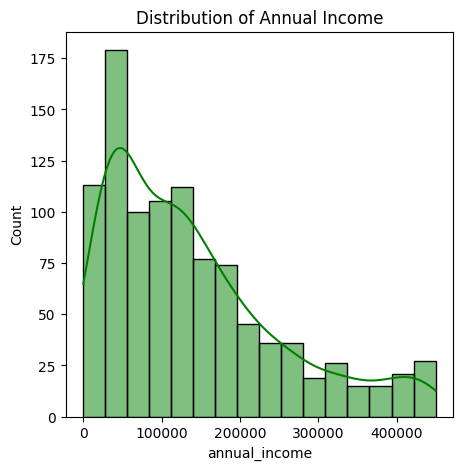

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(5,5))
sns.histplot(df_cust["annual_income"], kde=True, color='green', label='Data')
plt.title("Distribution of Annual Income")
plt.show()


In [ ]:
df_cust.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,1000.000000
mean,500.500000,36.405000,138916.765500
std,288.819436,15.666155,110969.408643
min,1.000000,1.000000,2.000000
25%,250.750000,26.000000,48229.500000
50%,500.500000,32.000000,113416.000000
75%,750.250000,46.000000,192614.000000
max,1000.000000,135.000000,449346.000000


In [ ]:
for index,row in df_cust.iterrows():
    if row["annual_income"]<100:
        df_cust.at[index,"annual_income"]=occupation_wise_inc_median[row["occupation"]]

In [ ]:
df_cust[df_cust.annual_income<100]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status


In [ ]:
df_cust.iloc[[31,316]]

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
31,32,Veer Gambhir,Male,50,City,Business Owner,261191.5,Married
316,317,Avinash Chauhan,Male,47,City,Consultant,58017.0,Married


In [ ]:
average_income_per_occupation=df_cust.groupby("occupation")["annual_income"].mean()
average_income_per_occupation

,annual_income
occupation,
Accountant,64123.562500
Artist,45309.236842
Business Owner,268447.368512
Consultant,60703.154639
Data Scientist,137021.266304
Freelancer,76327.508772
Fullstack Developer,78727.972973


/tmp/ipykernel_7160/689766619.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_income_per_occupation.index,y=average_income_per_occupation.values,palette="tab10")


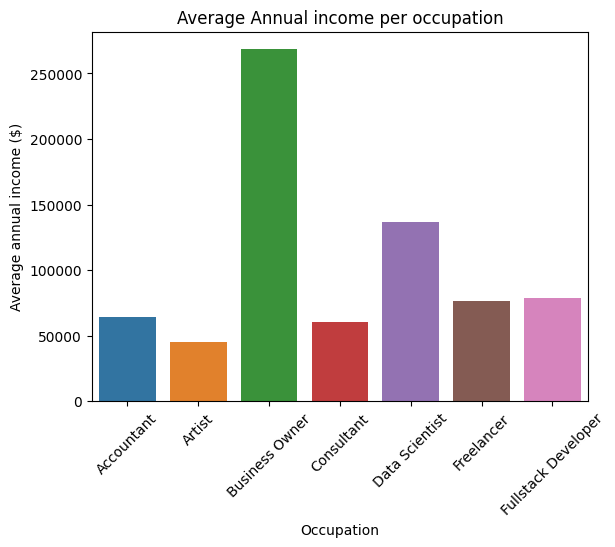

In [ ]:
sns.barplot(x=average_income_per_occupation.index,y=average_income_per_occupation.values,palette="tab10")
plt.xticks(rotation=45)
plt.title("Average Annual income per occupation")
plt.xlabel("Occupation")
plt.ylabel("Average annual income ($)")
plt.show()

/tmp/ipykernel_7160/1422302027.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7160/1422302027.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7160/1422302027.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_7160/1422302027.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


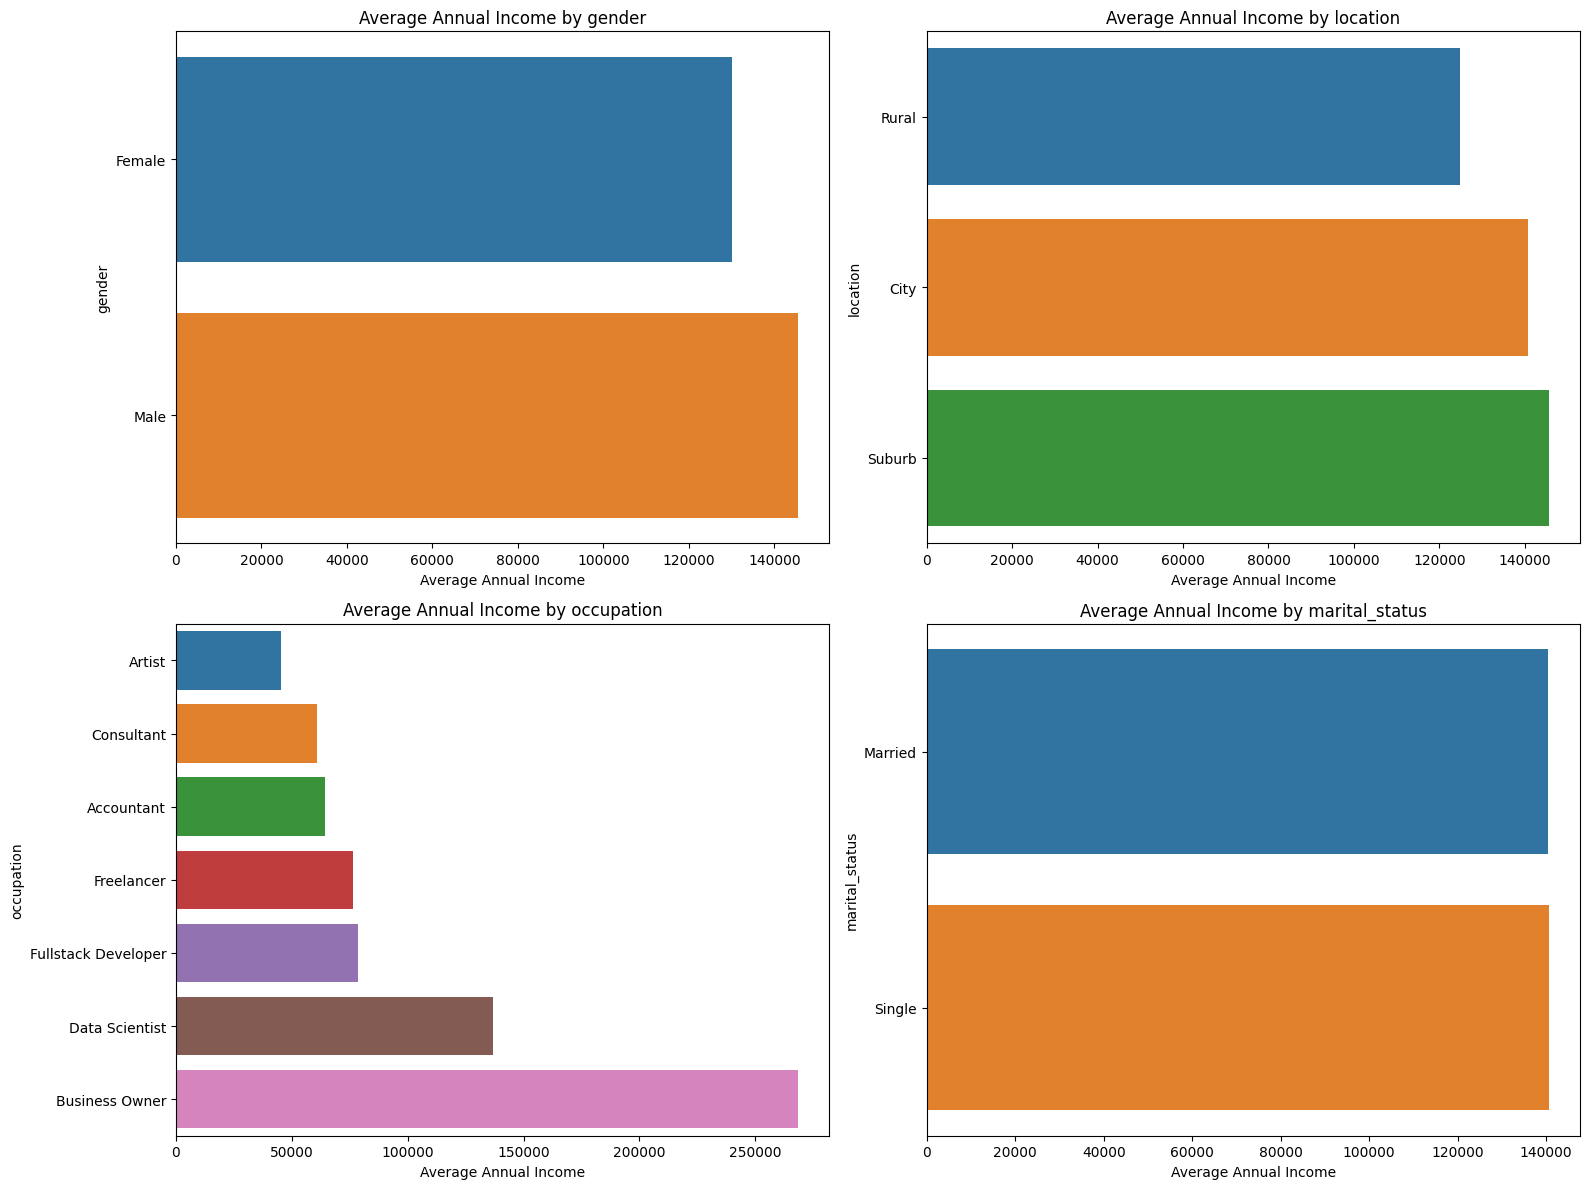

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_columns = ['gender', 'location', 'occupation', 'marital_status']

# Create a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()  # make indexing easier

for i, col in enumerate(categorical_columns):
    avg_income_per_group = (
        df_cust.groupby(col)['annual_income']
        .mean()
        .sort_values()
    )

    sns.barplot(
        x=avg_income_per_group.values,
        y=avg_income_per_group.index,
        ax=axes[i],
        palette='tab10'
    )

    axes[i].set_title(f'Average Annual Income by {col}')
    axes[i].set_xlabel('Average Annual Income')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()


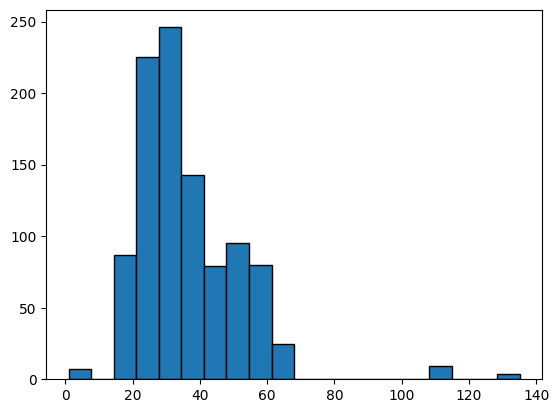

In [ ]:
plt.hist(df_cust.age,bins=20,edgecolor="black")
plt.show()

In [ ]:
outliers=df_cust[(df_cust.age<15)|(df_cust.age>80)]
outliers

,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Dhruv Bansal,Female,2,City,Business Owner,358211.0,Married
41,42,Manya Thakur,Male,110,City,Artist,7621.0,Married
165,166,Swara Mehtani,Female,1,City,Freelancer,39721.0,Single
174,175,Sneha Jaiswal,Male,110,City,Freelancer,23723.0,Married
222,223,Aaryan Bajaj,Male,110,Suburb,Freelancer,210987.0,Married
277,278,Amaira Dewan,Male,110,City,Consultant,96522.0,Single
295,296,Veer Anand,Male,1,Rural,Accountant,55254.0,Married
325,326,Yash Chatterjee,Male,110,City,Accountant,61021.0,Single
610,611,Advait Mangal,Male,135,Rural,Business Owner,444776.0,Married
692,693,Aarohi Dubey,Male,1,City,Business Owner,83045.0,Married


In [ ]:
median_age_per_occupation=df_cust.groupby("occupation")["age"].median()
median_age_per_occupation

,age
occupation,
Accountant,31.5
Artist,26.0
Business Owner,51.0
Consultant,46.0
Data Scientist,32.0
Freelancer,24.0
Fullstack Developer,27.5


In [ ]:
df_cust[(df_cust.age<15)|(df_cust.age>80)]


,cust_id,name,gender,age,location,occupation,annual_income,marital_status
0,1,Dhruv Bansal,Female,2,City,Business Owner,358211.0,Married
41,42,Manya Thakur,Male,110,City,Artist,7621.0,Married
165,166,Swara Mehtani,Female,1,City,Freelancer,39721.0,Single
174,175,Sneha Jaiswal,Male,110,City,Freelancer,23723.0,Married
222,223,Aaryan Bajaj,Male,110,Suburb,Freelancer,210987.0,Married
277,278,Amaira Dewan,Male,110,City,Consultant,96522.0,Single
295,296,Veer Anand,Male,1,Rural,Accountant,55254.0,Married
325,326,Yash Chatterjee,Male,110,City,Accountant,61021.0,Single
610,611,Advait Mangal,Male,135,Rural,Business Owner,444776.0,Married
692,693,Aarohi Dubey,Male,1,City,Business Owner,83045.0,Married


In [ ]:
df_cust.describe()

,cust_id,age,annual_income
count,1000.000000,1000.000000,1000.000000
mean,500.500000,36.405000,140483.548500
std,288.819436,15.666155,110463.002934
min,1.000000,1.000000,5175.000000
25%,250.750000,26.000000,49620.500000
50%,500.500000,32.000000,115328.000000
75%,750.250000,46.000000,195514.250000
max,1000.000000,135.000000,449346.000000


In [ ]:
bin_edges=[17,25,48,65]
bin_labels=['18-25','26-48','49-65']
df_cust['age_group']=pd.cut(df_cust['age'],bins=bin_edges,labels=bin_labels)
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group
0,1,Dhruv Bansal,Female,2,City,Business Owner,358211.0,Married,NaN
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single,26-48
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married,18-25
3,4,Sara Dwivedi,Male,24,Rural,Freelancer,33563.0,Married,18-25
4,5,Aarohi Negi,Male,48,City,Consultant,39406.0,Married,26-48


In [ ]:
age_group_counts=df_cust.age_group.value_counts(normalize=True)*100
age_group_counts

,proportion
age_group,
26-48,56.836735
18-25,24.489796
49-65,18.673469


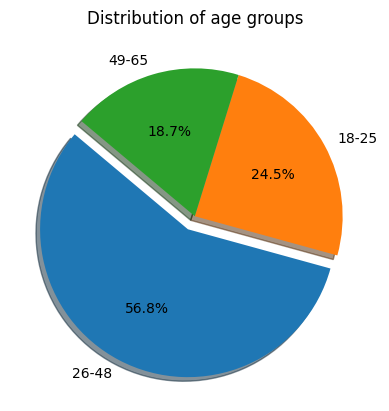

In [ ]:
plt.pie(age_group_counts,labels=age_group_counts.index,autopct='%1.1f%%',shadow=True,explode=(0.1,0,0),startangle=140)
plt.title("Distribution of age groups")
plt.show()

In [ ]:
customer_location_gender=df_cust.groupby(['location','gender']).size().unstack()
customer_location_gender

gender,Female,Male
location,,
City,226,457
Rural,26,59
Suburb,74,158


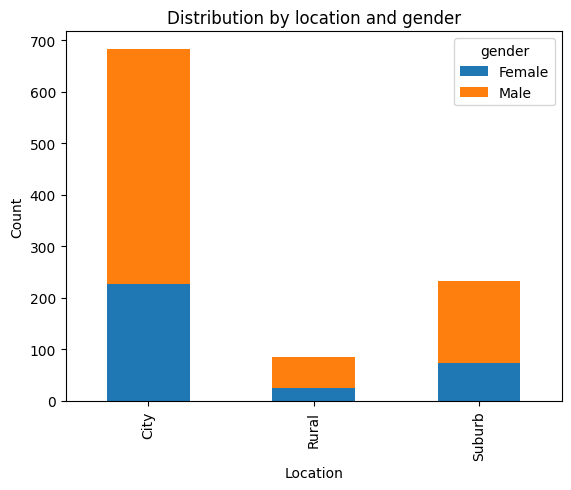

In [ ]:
customer_location_gender.plot(kind="bar",stacked=True)
plt.title("Distribution by location and gender")
plt.xlabel('Location')
plt.ylabel('Count')
plt.show()

In [ ]:
df_cs.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
0,1,749,0.585171,19571.0,0.0,40000.0
1,2,587,0.107928,161644.0,2.0,1250.0
2,3,544,0.854807,513.0,4.0,1000.0
3,4,504,0.336938,224.0,2.0,1000.0
4,5,708,0.586151,18090.0,2.0,40000.0


In [ ]:
df_cs.shape

(1004, 6)

In [ ]:
df_cs[df_cs['cust_id'].duplicated(keep=False)]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit
516,517,308,NaN,NaN,NaN,NaN
517,517,308,0.113860,33.0,3.0,500.0
569,569,344,NaN,NaN,NaN,NaN
570,569,344,0.112599,37.0,0.0,500.0
607,606,734,NaN,NaN,NaN,NaN
608,606,734,0.193418,4392.0,1.0,40000.0
664,662,442,NaN,NaN,NaN,NaN
665,662,442,0.856039,266.0,2.0,500.0


In [ ]:
df_cs_clean_l=df_cs.drop_duplicates(subset="cust_id",keep="last")
df_cs_clean_l.shape

(1000, 6)

In [ ]:
df_cs_clean_l[df_cs_clean_l['cust_id'].duplicated(keep=False)]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit


In [ ]:
df_cs_clean_l.isnull().sum()

,0
cust_id,0
credit_score,0
credit_utilisation,0
outstanding_debt,0
credit_inquiries_last_6_months,0
credit_limit,65


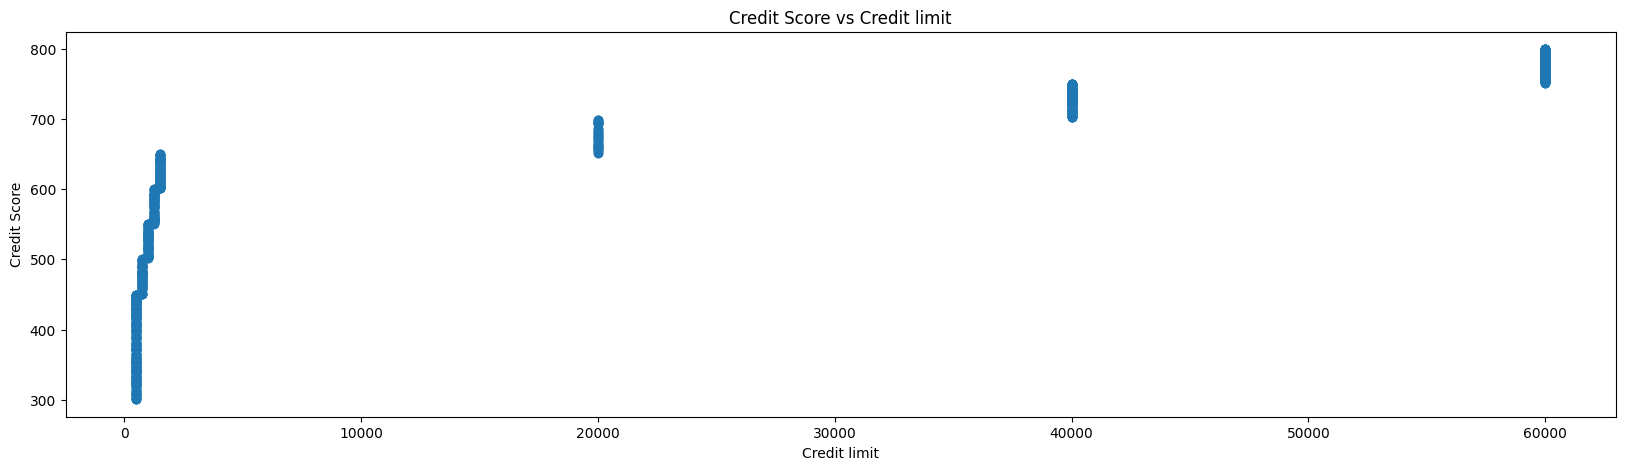

In [ ]:
plt.figure(figsize=(20,5))
plt.scatter(df_cs_clean_l.credit_limit,df_cs_clean_l.credit_score)
plt.title('Credit Score vs Credit limit')
plt.xlabel('Credit limit')
plt.ylabel('Credit Score')
plt.show()

In [ ]:
df_cs_clean_l.credit_limit.value_counts()

,count
credit_limit,
500.0,229
60000.0,186
40000.0,137
1500.0,100
1000.0,90
750.0,76
1250.0,75
20000.0,42


In [ ]:
df_cs_clean_l.credit_score.value_counts()

,count
credit_score,
736,8
799,8
771,8
781,7
775,7
...,...
416,1
687,1
644,1


In [ ]:
bin_ranges=[300,450,500,550,600,650,700,750,800]
bin_labels=[f'{start}-{end-1}' for start,end in zip(bin_ranges,bin_ranges[1:])]
df_cs_clean_l["credit_score_range"] = pd.cut(
    df_cs_clean_l['credit_score'],
    bins=bin_ranges,
    labels=bin_labels,
    right=True,
    include_lowest=True
)

/tmp/ipykernel_7160/884805979.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cs_clean_l["credit_score_range"] = pd.cut(


In [ ]:
df_cs_clean_l.head()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range
0,1,749,0.585171,19571.0,0.0,40000.0,700-749
1,2,587,0.107928,161644.0,2.0,1250.0,550-599
2,3,544,0.854807,513.0,4.0,1000.0,500-549
3,4,504,0.336938,224.0,2.0,1000.0,500-549
4,5,708,0.586151,18090.0,2.0,40000.0,700-749


In [ ]:
mode_df=df_cs_clean_l.groupby("credit_score_range")["credit_limit"].agg(lambda x:x.mode().iloc[0]).reset_index()
mode_df

/tmp/ipykernel_7160/2224840425.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mode_df=df_cs_clean_l.groupby("credit_score_range")["credit_limit"].agg(lambda x:x.mode().iloc[0]).reset_index()


,credit_score_range,credit_limit
0,300-449,500.0
1,450-499,750.0
2,500-549,1000.0
3,550-599,1250.0
4,600-649,1500.0
5,650-699,20000.0
6,700-749,40000.0
7,750-799,60000.0


In [ ]:
df_cs_clean_2=pd.merge(df_cs_clean_l,mode_df,on="credit_score_range",suffixes=("","_mode"))
df_cs_clean_2.sample(3)

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
863,864,566,0.853719,673.0,0.0,1250.0,550-599,1250.0
315,316,377,0.228065,90.0,3.0,500.0,300-449,500.0
67,68,388,0.138305,59.0,2.0,500.0,300-449,500.0


In [ ]:
df_cs_clean_3=df_cs_clean_2.copy()
df_cs_clean_3['credit_limit'] = df_cs_clean_3['credit_limit'].fillna(df_cs_clean_3['credit_limit_mode'])
df_cs_clean_3.shape

(1000, 8)

In [ ]:
df_cs_clean_3.isnull().sum()

,0
cust_id,0
credit_score,0
credit_utilisation,0
outstanding_debt,0
credit_inquiries_last_6_months,0
credit_limit,0
credit_score_range,0
credit_limit_mode,0


In [ ]:
df_cs_clean_3.describe()

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_limit_mode
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,589.182000,0.498950,9683.597000,1.955000,19733.500000,19733.500000
std,288.819436,152.284929,0.233139,25255.893671,1.414559,24717.629112,24717.629112
min,1.000000,300.000000,0.103761,33.000000,0.000000,500.000000,500.000000
25%,250.750000,460.000000,0.293917,221.000000,1.000000,750.000000,750.000000
50%,500.500000,601.500000,0.487422,550.000000,2.000000,1500.000000,1500.000000
75%,750.250000,738.000000,0.697829,11819.500000,3.000000,40000.000000,40000.000000
max,1000.000000,799.000000,0.899648,209901.000000,4.000000,60000.000000,60000.000000


In [ ]:
df_cs_clean_3[df_cs_clean_3.outstanding_debt>df_cs_clean_3.credit_limit]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
1,2,587,0.107928,161644.0,2.0,1250.0,550-599,1250.0
19,20,647,0.439132,205014.0,3.0,1500.0,600-649,1500.0
25,26,758,0.250811,190838.0,2.0,60000.0,750-799,60000.0
38,39,734,0.573023,122758.0,3.0,40000.0,700-749,40000.0
93,94,737,0.739948,137058.0,2.0,40000.0,700-749,40000.0
204,205,303,0.364360,187849.0,0.0,500.0,300-449,500.0
271,272,703,0.446886,154568.0,1.0,40000.0,700-749,40000.0
301,302,722,0.608076,122402.0,4.0,40000.0,700-749,40000.0
330,331,799,0.363420,208898.0,4.0,60000.0,750-799,60000.0
350,351,320,0.285081,150860.0,0.0,500.0,300-449,500.0


In [ ]:
df_cs_clean_3.loc[df_cs_clean_3.outstanding_debt>df_cs_clean_3.credit_limit,'outstanding_debt']=df_cs_clean_3['credit_limit']

In [ ]:
df_cs_clean_3[df_cs_clean_3.outstanding_debt>df_cs_clean_3.credit_limit]

,cust_id,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode


In [ ]:
df_merged=df_cust.merge(df_cs_clean_3,on="cust_id",how="inner")
df_merged.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
0,1,Dhruv Bansal,Female,2,City,Business Owner,358211.0,Married,NaN,749,0.585171,19571.0,0.0,40000.0,700-749,40000.0
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single,26-48,587,0.107928,1250.0,2.0,1250.0,550-599,1250.0
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married,18-25,544,0.854807,513.0,4.0,1000.0,500-549,1000.0
3,4,Sara Dwivedi,Male,24,Rural,Freelancer,33563.0,Married,18-25,504,0.336938,224.0,2.0,1000.0,500-549,1000.0
4,5,Aarohi Negi,Male,48,City,Consultant,39406.0,Married,26-48,708,0.586151,18090.0,2.0,40000.0,700-749,40000.0


In [ ]:
numerical_cols=['credit_score','credit_utilisation','outstanding_debt','credit_limit','annual_income','age']
correlation_matrix=df_merged[numerical_cols].corr()
correlation_matrix

,credit_score,credit_utilisation,outstanding_debt,credit_limit,annual_income,age
credit_score,1.000000,-0.070445,0.680654,0.847951,0.575751,0.356911
credit_utilisation,-0.070445,1.000000,0.192838,-0.080504,-0.086368,-0.026364
outstanding_debt,0.680654,0.192838,1.000000,0.810581,0.555661,0.327208
credit_limit,0.847951,-0.080504,0.810581,1.000000,0.684780,0.402161
annual_income,0.575751,-0.086368,0.555661,0.684780,1.000000,0.480542
age,0.356911,-0.026364,0.327208,0.402161,0.480542,1.000000


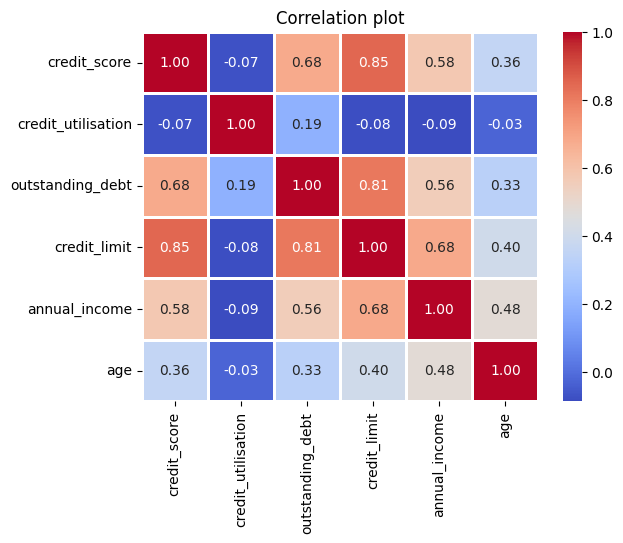

In [ ]:
sns.heatmap(correlation_matrix,annot=True,fmt=".2f",cmap='coolwarm',linewidth=0.8)
plt.title("Correlation plot")
plt.show()

In [ ]:
df_trans.isnull().sum()

,0
tran_id,0
cust_id,0
tran_date,0
tran_amount,0
platform,4941
product_category,0
payment_type,0


In [ ]:
df_trans.platform.value_counts()

,count
platform,
Amazon,151443
Flipkart,122660
Alibaba,73584
Meesho,73271
Shopify,39416
Cred,24741
Ebay,9944


<Axes: xlabel='count', ylabel='product_category'>

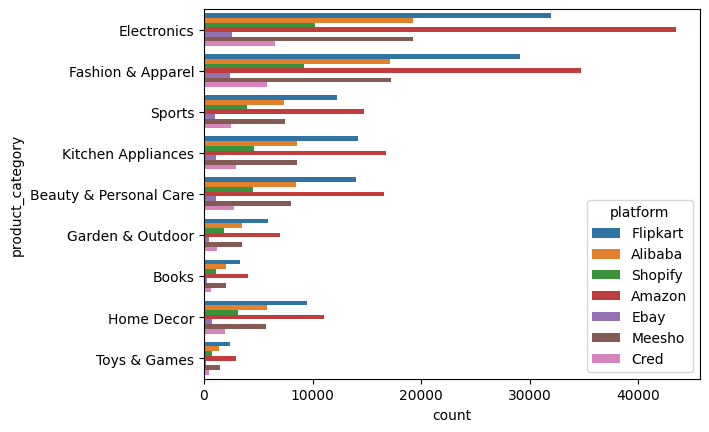

In [ ]:
sns.countplot(y="product_category",hue="platform",data=df_trans)

In [ ]:
df_trans['platform'] = df_trans['platform'].fillna(df_trans['platform'].mode()[0])

In [ ]:
df_trans.isnull().sum()


,0
tran_id,0
cust_id,0
tran_date,0
tran_amount,0
platform,0
product_category,0
payment_type,0


In [ ]:
df_trans.describe()

,tran_id,cust_id,tran_amount
count,500000.000000,500000.000000,500000.00000
mean,250000.500000,501.400428,3225.20733
std,144337.711634,288.641924,13098.74276
min,1.000000,1.000000,0.00000
25%,125000.750000,252.000000,64.00000
50%,250000.500000,502.000000,141.00000
75%,375000.250000,752.000000,397.00000
max,500000.000000,1000.000000,69999.00000


In [ ]:
df_trans_zero=df_trans[df_trans.tran_amount==0]
df_trans_zero.shape

(4734, 7)

In [ ]:
df_trans_zero.payment_type.value_counts()

,count
payment_type,
Credit Card,4734


In [ ]:
df_trans_l=df_trans[(df_trans.platform=='Amazon') & (df_trans.product_category=='Electronics') & (df_trans.payment_type=='Credit Card')]
df_trans_l.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
109,110,887,2023-01-01,635,Amazon,Electronics,Credit Card
120,121,440,2023-01-01,0,Amazon,Electronics,Credit Card
141,142,839,2023-01-01,0,Amazon,Electronics,Credit Card
173,174,676,2023-01-01,60439,Amazon,Electronics,Credit Card
190,191,763,2023-01-01,697,Amazon,Electronics,Credit Card


In [ ]:
median_to_replace=df_trans_l[df_trans_l.tran_amount>0].tran_amount.median()
median_to_replace

554.0

In [ ]:
df_trans['tran_amount'].replace(0,median_to_replace,inplace=True)

/tmp/ipykernel_7160/2400713182.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_trans['tran_amount'].replace(0,median_to_replace,inplace=True)


In [ ]:
df_trans.describe()

,tran_id,cust_id,tran_amount
count,500000.000000,500000.000000,500000.000000
mean,250000.500000,501.400428,3230.452602
std,144337.711634,288.641924,13097.561071
min,1.000000,1.000000,2.000000
25%,125000.750000,252.000000,66.000000
50%,250000.500000,502.000000,146.000000
75%,375000.250000,752.000000,413.000000
max,500000.000000,1000.000000,69999.000000


<Axes: xlabel='tran_amount', ylabel='Count'>

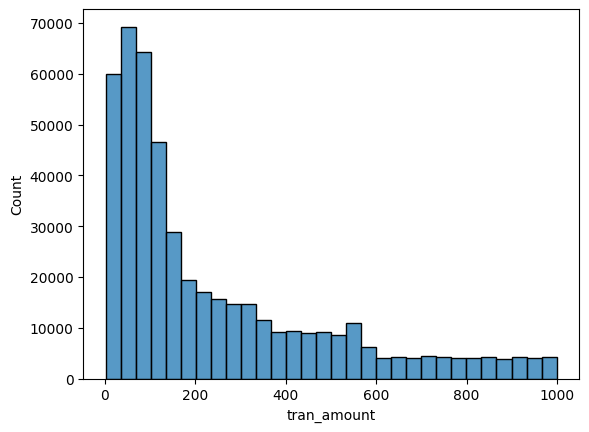

In [ ]:
sns.histplot(df_trans[df_trans.tran_amount<10000].tran_amount,bins=30)

In [ ]:
Q1,Q3=df_trans['tran_amount'].quantile([0.25,0.75])
IQR=Q3-Q1
lower=Q1-2*IQR
upper=Q3+2*IQR
lower,upper

(-628.0, 1107.0)

In [ ]:
df_tran_outliers=df_trans[df_trans['tran_amount']>=upper]
df_tran_outliers.shape

(25000, 7)

In [ ]:
df_trans_normal=df_trans[df_trans.tran_amount<upper]
df_trans_normal.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking


In [ ]:
tran_mean_per_category=df_trans_normal.groupby("product_category")["tran_amount"].mean()
tran_mean_per_category

,tran_amount
product_category,
Beauty & Personal Care,92.167205
Books,29.553515
Electronics,510.172685
Fashion & Apparel,64.553463
Garden & Outdoor,125.630277
Home Decor,302.487561
Kitchen Appliances,176.773288
Sports,269.181631
Toys & Games,50.333298


In [ ]:
df_tran_outliers.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
26,27,380,2023-01-01,61963,Shopify,Beauty & Personal Care,Credit Card
49,50,287,2023-01-01,57869,Amazon,Toys & Games,Gpay
94,95,770,2023-01-01,52881,Ebay,Kitchen Appliances,Credit Card
104,105,549,2023-01-01,58574,Flipkart,Fashion & Apparel,Gpay
113,114,790,2023-01-01,51669,Shopify,Kitchen Appliances,Credit Card


In [ ]:
df_trans.loc[df_tran_outliers.index].head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
26,27,380,2023-01-01,61963,Shopify,Beauty & Personal Care,Credit Card
49,50,287,2023-01-01,57869,Amazon,Toys & Games,Gpay
94,95,770,2023-01-01,52881,Ebay,Kitchen Appliances,Credit Card
104,105,549,2023-01-01,58574,Flipkart,Fashion & Apparel,Gpay
113,114,790,2023-01-01,51669,Shopify,Kitchen Appliances,Credit Card


<Axes: xlabel='payment_type', ylabel='percent'>

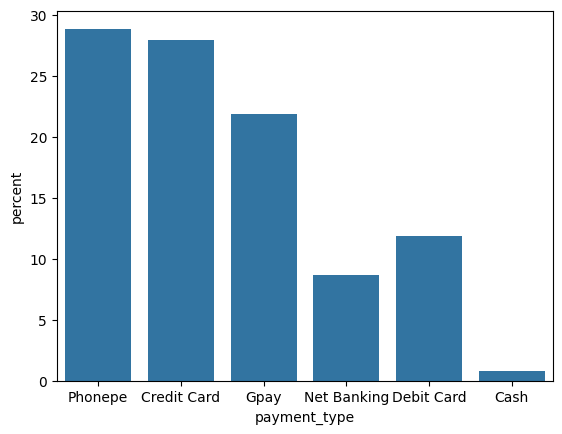

In [ ]:
sns.countplot(x=df_trans.payment_type,stat='percent')

In [ ]:
df_trans.head()

,tran_id,cust_id,tran_date,tran_amount,platform,product_category,payment_type
0,1,705,2023-01-01,63,Flipkart,Electronics,Phonepe
1,2,385,2023-01-01,99,Alibaba,Fashion & Apparel,Credit Card
2,3,924,2023-01-01,471,Shopify,Sports,Phonepe
3,4,797,2023-01-01,33,Shopify,Fashion & Apparel,Gpay
4,5,482,2023-01-01,68,Amazon,Fashion & Apparel,Net Banking


In [ ]:
df_cust.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group
0,1,Dhruv Bansal,Female,2,City,Business Owner,358211.0,Married,NaN
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single,26-48
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married,18-25
3,4,Sara Dwivedi,Male,24,Rural,Freelancer,33563.0,Married,18-25
4,5,Aarohi Negi,Male,48,City,Consultant,39406.0,Married,26-48


In [ ]:
df_merged.head()

,cust_id,name,gender,age,location,occupation,annual_income,marital_status,age_group,credit_score,credit_utilisation,outstanding_debt,credit_inquiries_last_6_months,credit_limit,credit_score_range,credit_limit_mode
0,1,Dhruv Bansal,Female,2,City,Business Owner,358211.0,Married,NaN,749,0.585171,19571.0,0.0,40000.0,700-749,40000.0
1,2,Kabir Thakur,Female,47,City,Consultant,65172.0,Single,26-48,587,0.107928,1250.0,2.0,1250.0,550-599,1250.0
2,3,Kriti Mangal,Male,21,City,Freelancer,22378.0,Married,18-25,544,0.854807,513.0,4.0,1000.0,500-549,1000.0
3,4,Sara Dwivedi,Male,24,Rural,Freelancer,33563.0,Married,18-25,504,0.336938,224.0,2.0,1000.0,500-549,1000.0
4,5,Aarohi Negi,Male,48,City,Consultant,39406.0,Married,26-48,708,0.586151,18090.0,2.0,40000.0,700-749,40000.0


In [ ]:
df_merged_2=pd.merge(df_merged,df_trans,on="cust_id",how="inner")
df_merged_2.shape

(500000, 22)

In [ ]:
df_merged_2.columns

Index(['cust_id', 'name', 'gender', 'age', 'location', 'occupation',
       'annual_income', 'marital_status', 'age_group', 'credit_score',
       'credit_utilisation', 'outstanding_debt',
       'credit_inquiries_last_6_months', 'credit_limit', 'credit_score_range',
       'credit_limit_mode', 'tran_id', 'tran_date', 'tran_amount', 'platform',
       'product_category', 'payment_type'],
      dtype='object')

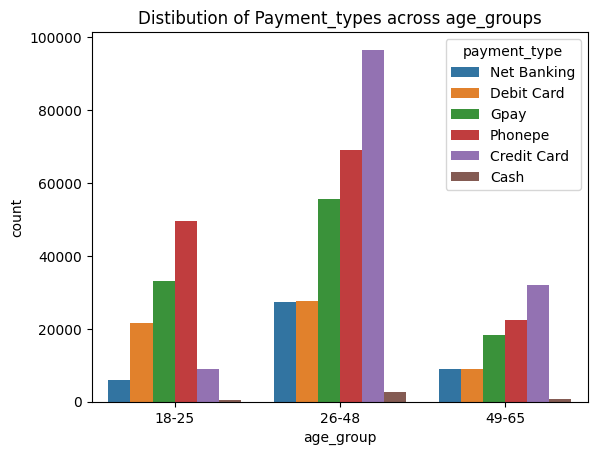

In [ ]:
sns.countplot(x='age_group',hue='payment_type',data=df_merged_2)
plt.title("Distibution of Payment_types across age_groups")
plt.show()

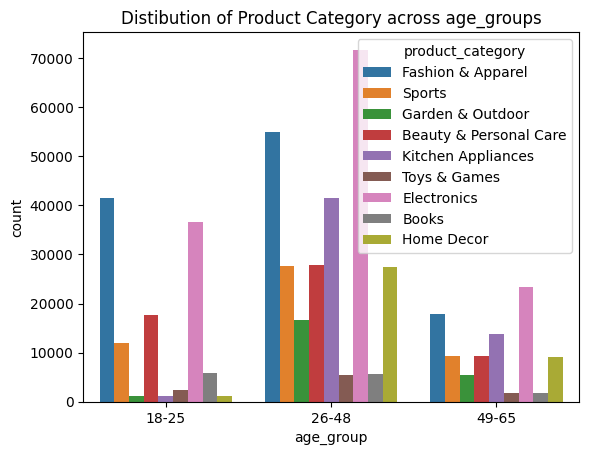

In [ ]:
sns.countplot(x='age_group',hue='product_category',data=df_merged_2)
plt.title("Distibution of Product Category across age_groups")
plt.show()

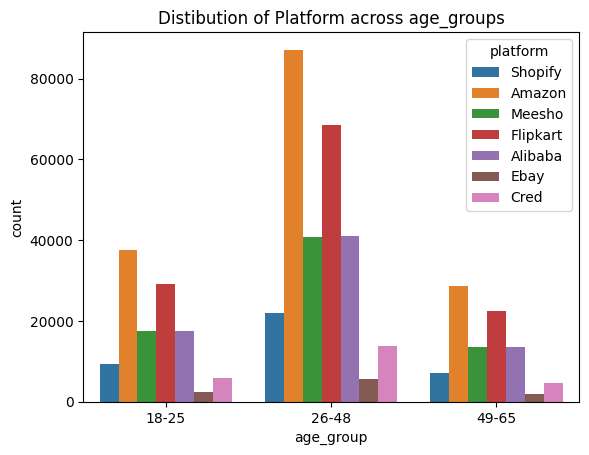

In [ ]:
sns.countplot(x='age_group',hue='platform',data=df_merged_2)
plt.title("Distibution of Platform across age_groups")
plt.show()

/tmp/ipykernel_7160/3341933186.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=cat_col, y='tran_amount', data=sorted_data, ci=None, ax=axes[i], palette='tab10')
/tmp/ipykernel_7160/3341933186.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_col, y='tran_amount', data=sorted_data, ci=None, ax=axes[i], palette='tab10')
/tmp/ipykernel_7160/3341933186.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
/tmp/ipykernel_7160/3341933186.py:18: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=cat_col, y='tran_amount', data=sorted_data, ci=None, ax=axes[i], palette=

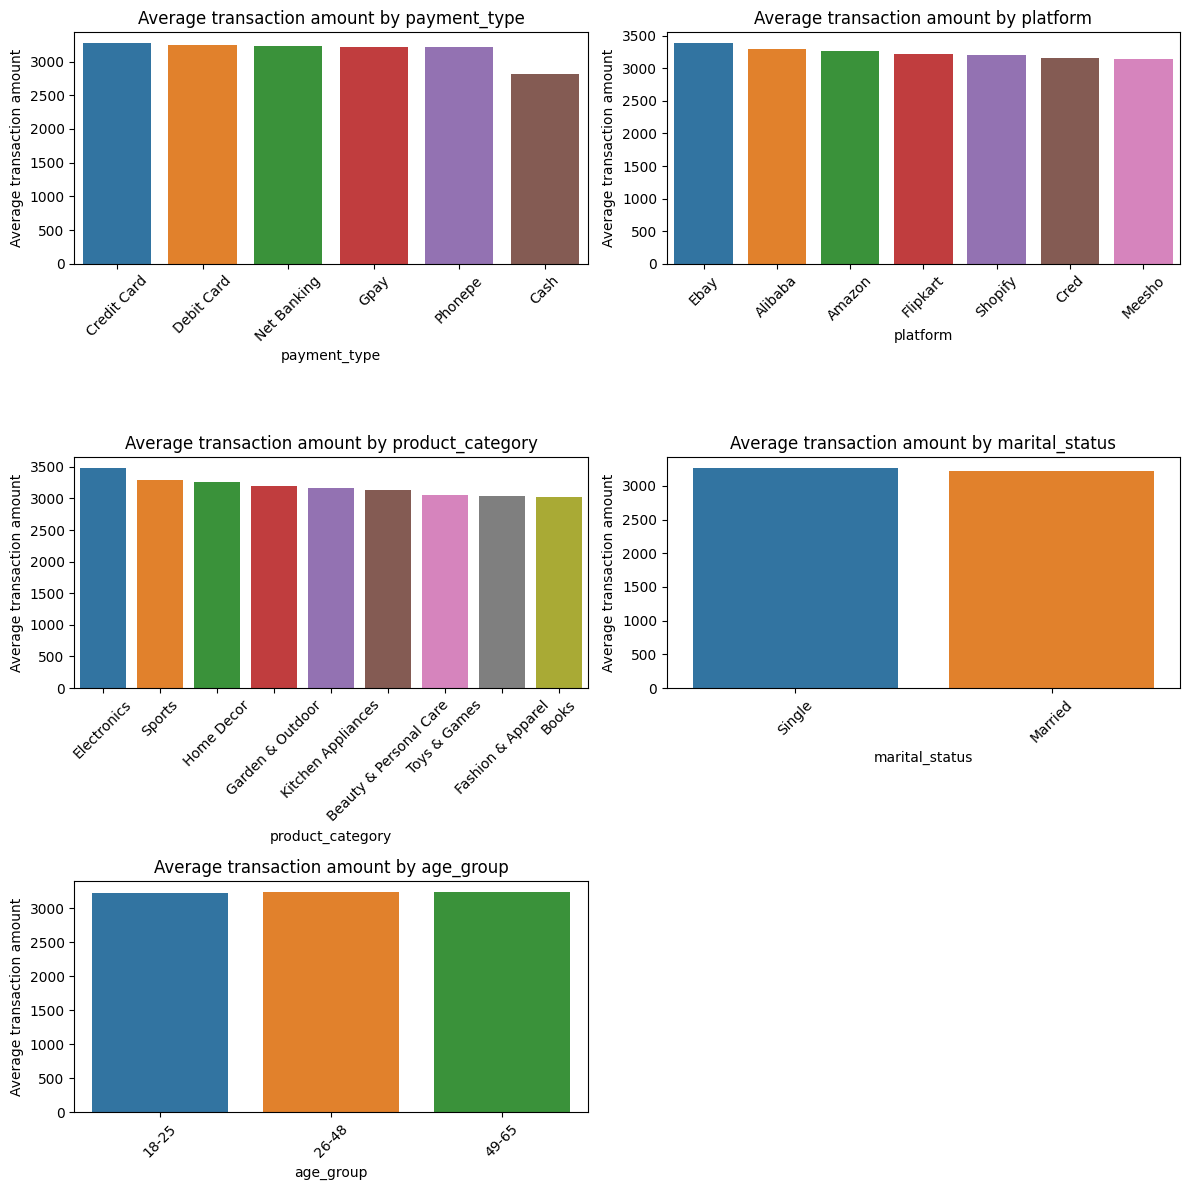

In [ ]:
cat_cols = ['payment_type', 'platform', 'product_category', 'marital_status', 'age_group']

num_rows = 3
# Create subplots
fig, axes = plt.subplots(num_rows, 2, figsize=(12, 4 * num_rows))

# Flatten the axes array to make it easier to iterate
axes = axes.flatten()

# Create subplots for each categorical column
for i, cat_col in enumerate(cat_cols):
    # Calculate the average annual income for each category
    avg_tran_amount_by_category = df_merged_2.groupby(cat_col)['tran_amount'].mean().reset_index()

    # Sort the data by 'annual_income' before plotting
    sorted_data = avg_tran_amount_by_category.sort_values(by='tran_amount', ascending=False)

    sns.barplot(x=cat_col, y='tran_amount', data=sorted_data, ci=None, ax=axes[i], palette='tab10')
    axes[i].set_title(f'Average transaction amount by {cat_col}')
    axes[i].set_xlabel(cat_col)
    axes[i].set_ylabel('Average transaction amount')

    # Rotate x-axis labels for better readability
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)

# Hide any unused subplots
for i in range(len(cat_cols), len(axes)):
    fig.delaxes(axes[i])
plt.tight_layout()
plt.show()

In [ ]:
age_group_metrics = df_merged.groupby('age_group')[['annual_income', 'credit_limit', 'credit_score']].mean().reset_index()
age_group_metrics

/tmp/ipykernel_7160/2478570349.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_metrics = df_merged.groupby('age_group')[['annual_income', 'credit_limit', 'credit_score']].mean().reset_index()


,age_group,annual_income,credit_limit,credit_score
0,18-25,36347.695833,886.458333,482.216667
1,26-48,147395.675943,20702.423698,598.017953
2,49-65,258918.907104,41729.508197,701.103825


/tmp/ipykernel_7160/2543336237.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='annual_income', data=age_group_metrics, palette='tab10', ax=ax1)
/tmp/ipykernel_7160/2543336237.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='credit_limit', data=age_group_metrics, palette='hls', ax=ax2)
/tmp/ipykernel_7160/2543336237.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_group', y='credit_score', data=age_group_metrics, palette='viridis', ax=ax3)


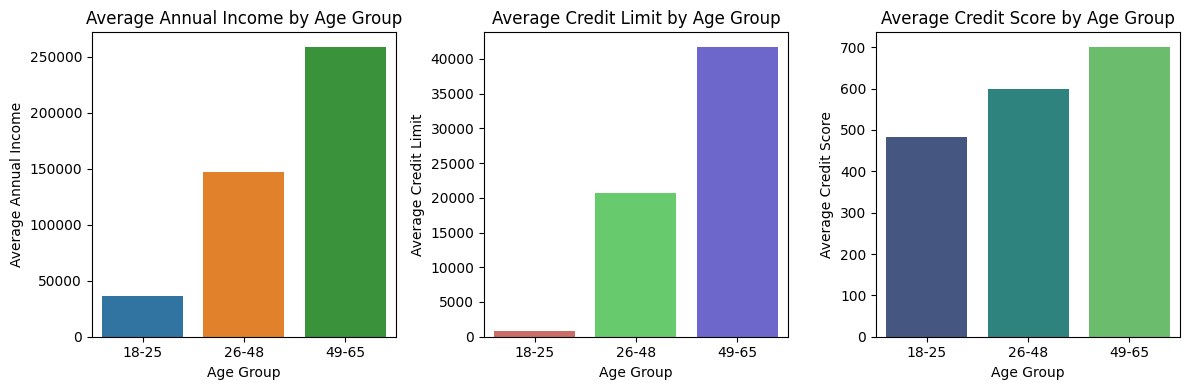

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

# Plot 1: Average annual income by age group
sns.barplot(x='age_group', y='annual_income', data=age_group_metrics, palette='tab10', ax=ax1)
ax1.set_title('Average Annual Income by Age Group')
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Average Annual Income')
ax1.tick_params(axis='x', rotation=0)

# Plot 2: Average Max Credit Limit by Age Group
sns.barplot(x='age_group', y='credit_limit', data=age_group_metrics, palette='hls', ax=ax2)
ax2.set_title('Average Credit Limit by Age Group')
ax2.set_xlabel('Age Group')
ax2.set_ylabel('Average Credit Limit')
ax2.tick_params(axis='x', rotation=0)

# Plot 3: Average Credit Score by Age Group
sns.barplot(x='age_group', y='credit_score', data=age_group_metrics, palette='viridis', ax=ax3)
ax3.set_title('Average Credit Score by Age Group')
ax3.set_xlabel('Age Group')
ax3.set_ylabel('Average Credit Score')
ax3.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
import statsmodels.stats.api as sms
import statsmodels.api as sm
import pandas as pd
import numpy as np
from scipy import stats as st
from matplotlib import pyplot as plt
import seaborn as sns

In [ ]:
alpha=0.05
power=0.8
effect_size=0.2
sms.tt_ind_solve_power(
    effect_size=effect_size,
    alpha=alpha,
    power=power,
    ratio=1,
    alternative='two-sided'
)

393.40569300025163

In [ ]:
# Calculate the required sample size for different effect sizes
effect_sizes = [0.1, 0.2, 0.3, 0.4, 0.5, 1]

for effect_size in effect_sizes:
    sample_size = sms.tt_ind_solve_power(
        effect_size=effect_size,
        alpha=alpha,
        power=power,
        ratio=1,
        alternative='two-sided'
    )
    print(f"Effect Size: {effect_size}, Required Sample size: {sample_size:.0f} customers")


Effect Size: 0.1, Required Sample size: 1571 customers
Effect Size: 0.2, Required Sample size: 393 customers
Effect Size: 0.3, Required Sample size: 175 customers
Effect Size: 0.4, Required Sample size: 99 customers
Effect Size: 0.5, Required Sample size: 64 customers
Effect Size: 1, Required Sample size: 17 customers


Forming control and test groups
1.We have identified approximately 246 customers within the age group of 18 to 25. From this pool, we will select 100 customers for the initial campaign launch.

2.The campaign is launched for 100 customers, as determined by the effective size calculation and by considering budgeting costs, and will run campaign for a duration of 2 months

3.Got a conversion rate of ~40% ( implies 40 out of 100 customers in test group started using credit card)

4.To maintain a similar sample size, a control group consisting of 40 customers will be created. Importantly, this control group will be completely exclusive of initial 100 customers used as test group.

5.So now we have 40 customers in each of control and test groups

In [ ]:
import pandas as pd
df = pd.read_csv('avg_transactions_after_campaign.csv')
df.head(4)

,campaign_date,control_group_avg_tran,test_group_avg_tran
0,2023-09-10,251.02,401.78
1,2023-09-11,250.77,326.16
2,2023-09-12,248.81,303.92
3,2023-09-13,255.90,363.29


In [ ]:
df.shape

(62, 3)

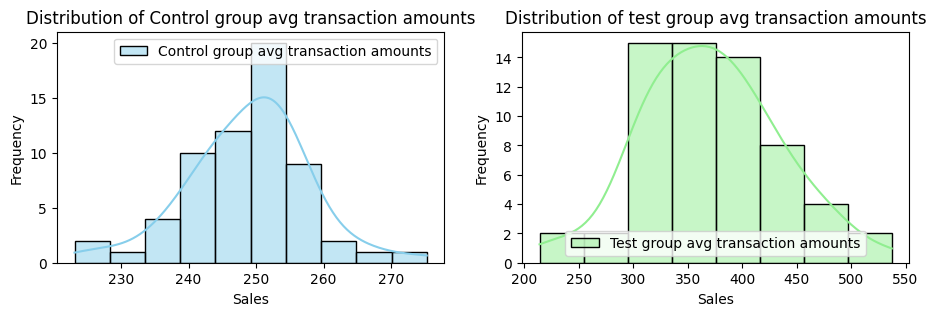

In [ ]:
# Let's look at distributions of avg transactions amounts in both groups
# Create a 1x2 grid of subplots
import matplotlib.pyplot as plt
import seaborn as sns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3))

# Plot the distribution of Campaign A Sales
sns.histplot(df['control_group_avg_tran'], kde=True, color='skyblue', label='Control group avg transaction amounts', ax=ax1)
ax1.set_xlabel('Sales')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Control group avg transaction amounts')
ax1.legend()

# Plot the distribution of Campaign B Sales
sns.histplot(df['test_group_avg_tran'], kde=True, color='lightgreen', label='Test group avg transaction amounts', ax=ax2)
ax2.set_xlabel('Sales')
ax2.set_ylabel('Frequency')
ax2.set_title('Distribution of test group avg transaction amounts')
ax2.legend()

# Show the plots
plt.show()

In [ ]:
control_mean = df["control_group_avg_tran"].mean()
control_std = df["control_group_avg_tran"].std()
control_mean, control_std

(np.float64(248.94129032258064), 9.137869049553624)

In [ ]:
test_mean = df["test_group_avg_tran"].mean()
test_std = df["test_group_avg_tran"].std()
test_mean, test_std

(np.float64(370.5364516129033), 63.25415113953285)

In [ ]:
sample_size = df.shape[0]
sample_size

62

Null Hypothesis (H₀):The new credit card does not increase the average transaction amount compared to the existing credit card

Alternative Hypothesis (H₁):The new credit card increases the average transaction amount compared to the existing credit card

Test Using Rejection Region (i.e. Critical Z Value)

In [ ]:
import numpy as np
a = (control_std**2/sample_size)
b = (test_std**2/sample_size)

Z_score = (test_mean-control_mean)/np.sqrt(a+b)
Z_score

np.float64(14.980903070990523)

In [ ]:
# For a significance level of 5% (0.05) in a right-tailed test, the critical Z-value is approximately 1.645
from scipy import stats as st
alpha=0.05
critical_z_value = st.norm.ppf(1 - alpha)  # Right-tailed test at 5% significance level
critical_z_value

np.float64(1.6448536269514722)

In [ ]:
Z_score > critical_z_value

np.True_

Since Z score is higher than critical Z value, we can reject the null hypothesis.

Test Using p-Value

In [ ]:
# Calculate the p-value corresponding to z score for a right-tailed test
p_value = 1 - st.norm.cdf(Z_score)
p_value

np.float64(0.0)

In [ ]:
p_value < alpha # p value is less than significance level of 5% (or 0.05 for absolute value)

np.True_

Since p value is less than significance level (i.e. alpha), we can reject the null hypothesis.

In [ ]:
test_group_CI=st.norm.interval(0.95,loc=test_mean,scale=test_std/np.sqrt(sample_size))
test_group_CI

(np.float64(354.79150188846626), np.float64(386.28140133734036))

In [ ]:
campaign_start_date = pd.to_datetime(df['campaign_date'].min())
campaign_start_date

Timestamp('2023-09-10 00:00:00')

In [ ]:
df_main = df_merged_2.copy()

df_main['tran_date'] = pd.to_datetime(df_main['tran_date'])

In [ ]:
df_target = df_main[(df_main['age'] >= 18) & (df_main['age'] <= 25)]

In [ ]:
df_post = df_target.copy()

In [ ]:
df_post['annual_income'].describe()

,annual_income
count,119559.000000
mean,36374.357756
std,18314.067258
min,5708.000000
25%,22930.000000
50%,37345.000000
75%,47665.000000
max,135759.000000


In [ ]:
bins = [0, 22930, 47665, float('inf')]
labels = ['Low', 'Medium', 'High']

df_post['income_tier'] = pd.cut(df_post['annual_income'], bins=bins, labels=labels)

In [ ]:
df_post['income_tier'].value_counts()

,count
income_tier,
Medium,59929
Low,30211
High,29419


In [ ]:
df_spending = df_post.groupby(['cust_id', 'income_tier'])['tran_amount'].sum().reset_index()

/tmp/ipykernel_7160/2883194684.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_spending = df_post.groupby(['cust_id', 'income_tier'])['tran_amount'].sum().reset_index()


In [ ]:
low = df_spending[df_spending['income_tier'] == 'Low']['tran_amount']
medium = df_spending[df_spending['income_tier'] == 'Medium']['tran_amount']
high = df_spending[df_spending['income_tier'] == 'High']['tran_amount']

In [ ]:
from scipy import stats

f_stat, p_value = stats.f_oneway(low, medium, high)

print("F-statistic:", f_stat)
print("P-value:", p_value)

F-statistic: 23.414844305802696
P-value: 1.4104563946606532e-10


In [ ]:
alpha = 0.05

if p_value < alpha:
    print("Significant difference in spending across income tiers")
else:
    print("No significant difference")

Significant difference in spending across income tiers


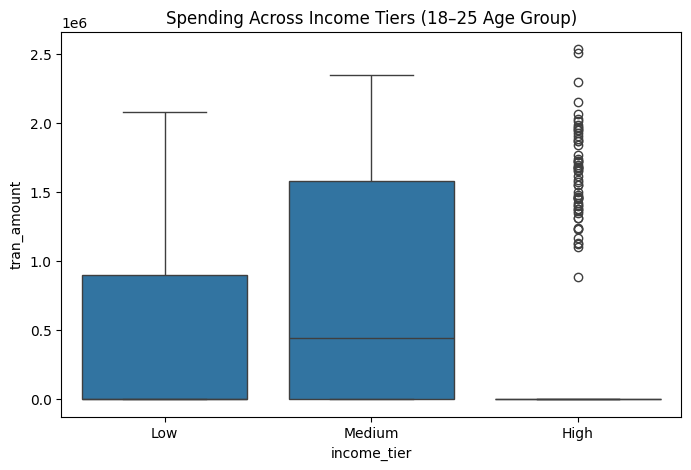

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x='income_tier', y='tran_amount', data=df_spending)
plt.title("Spending Across Income Tiers (18–25 Age Group)")
plt.show()

In [ ]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

In [ ]:
tukey = pairwise_tukeyhsd(
    endog=df_spending['tran_amount'],      # dependent variable
    groups=df_spending['income_tier'],     # group variable
    alpha=0.05
)

print(tukey)

      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
group1 group2   meandiff  p-adj     lower        upper    reject
----------------------------------------------------------------
  High    Low  -8490.4792 0.9916 -170099.9997 153119.0414  False
  High Medium 403492.6375    0.0  241883.1169 565102.1581   True
   Low Medium 411983.1167    0.0  250373.5961 573592.6372   True
----------------------------------------------------------------


/tmp/ipykernel_7160/3530422166.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='income_tier', y='tran_amount', data=df_spending,


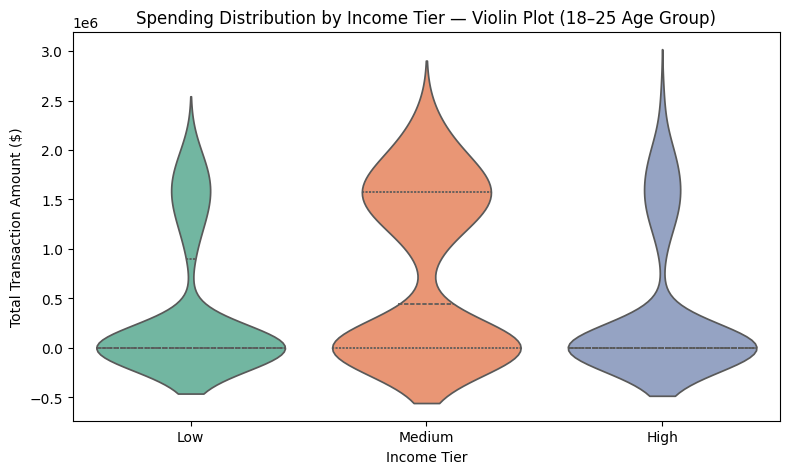

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
sns.violinplot(x='income_tier', y='tran_amount', data=df_spending,
               palette='Set2', inner='quartile', order=['Low', 'Medium', 'High'])
plt.title("Spending Distribution by Income Tier — Violin Plot (18–25 Age Group)")
plt.xlabel("Income Tier")
plt.ylabel("Total Transaction Amount ($)")
plt.tight_layout()
plt.show()

/tmp/ipykernel_7160/2457658951.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df_spending.groupby('income_tier')['tran_amount'].agg(['mean', 'std', 'count']).reset_index()


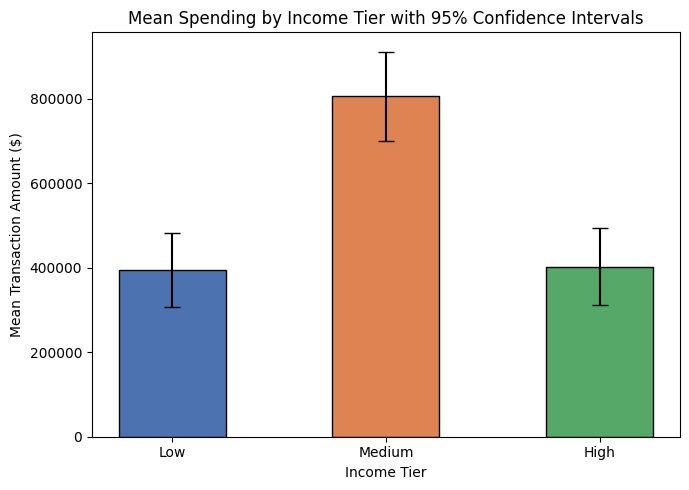

In [ ]:
import numpy as np
from scipy import stats

group_stats = df_spending.groupby('income_tier')['tran_amount'].agg(['mean', 'std', 'count']).reset_index()
group_stats['se'] = group_stats['std'] / np.sqrt(group_stats['count'])
group_stats['ci95'] = group_stats['se'] * 1.96
group_stats['income_tier'] = pd.Categorical(group_stats['income_tier'], categories=['Low', 'Medium', 'High'], ordered=True)
group_stats = group_stats.sort_values('income_tier')

plt.figure(figsize=(7, 5))
plt.bar(group_stats['income_tier'], group_stats['mean'],
        yerr=group_stats['ci95'], capsize=6,
        color=['#4C72B0', '#DD8452', '#55A868'], edgecolor='black', width=0.5)
plt.title("Mean Spending by Income Tier with 95% Confidence Intervals")
plt.xlabel("Income Tier")
plt.ylabel("Mean Transaction Amount ($)")
plt.tight_layout()
plt.show()

## Phase 4: Customer Segmentation — Targeting the 18–25 Age Group
### Objective: Identify distinct sub-segments within our target group to design personalised credit card offerings

In [ ]:
import pandas as pd
import numpy as np

# Filter only 18-25 age group
df_target_18_25 = df_merged_2[
    (df_merged_2['age'] >= 18) & (df_merged_2['age'] <= 25)
].copy()

# Aggregate transaction behaviour per customer
trans_agg = df_target_18_25.groupby('cust_id').agg(
    total_spending=('tran_amount', 'sum'),
    avg_transaction=('tran_amount', 'mean'),
    txn_count=('tran_amount', 'count')
).reset_index()

# Get unique customer-level profile features
profile_cols = ['cust_id', 'age', 'annual_income', 'credit_score',
                'credit_utilisation', 'credit_limit', 'outstanding_debt']
cust_profile = df_target_18_25[profile_cols].drop_duplicates('cust_id')

# Merge transactions
cluster_df = cust_profile.merge(trans_agg, on='cust_id', how='inner').dropna()

# ✅ Add income tier — same bins used in ANOVA section
bins   = [0, 22930, 47665, float('inf')]
labels = ['Low', 'Medium', 'High']
cluster_df['income_tier'] = pd.cut(cluster_df['annual_income'], bins=bins, labels=labels)

print(f"Customers in 18–25 target group: {cluster_df.shape[0]}")
print("\nIncome tier distribution:")
print(cluster_df['income_tier'].value_counts().sort_index())
cluster_df.head()

Customers in 18–25 target group: 240

Income tier distribution:
income_tier
Low        61
Medium    120
High       59
Name: count, dtype: int64


,cust_id,age,annual_income,credit_score,credit_utilisation,credit_limit,outstanding_debt,total_spending,avg_transaction,txn_count,income_tier
0,3,21,22378.0,544,0.854807,1000.0,513.0,1932123,3951.171779,489,Low
1,4,24,33563.0,504,0.336938,1000.0,224.0,1770984,3392.689655,522,Medium
2,6,22,44887.0,442,0.705409,500.0,246.0,2201992,4412.809619,499,Medium
3,9,21,34814.0,537,0.448924,1000.0,341.0,1567623,2957.779245,530,Medium
4,10,25,39832.0,567,0.533402,1250.0,522.0,1361751,2756.580972,494,Medium


In [ ]:
from sklearn.preprocessing import StandardScaler

features = ['age', 'annual_income', 'credit_score', 'credit_utilisation',
            'credit_limit', 'outstanding_debt', 'total_spending', 'avg_transaction', 'txn_count']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[features])

print("Feature matrix shape:", X_scaled.shape)

Feature matrix shape: (240, 9)


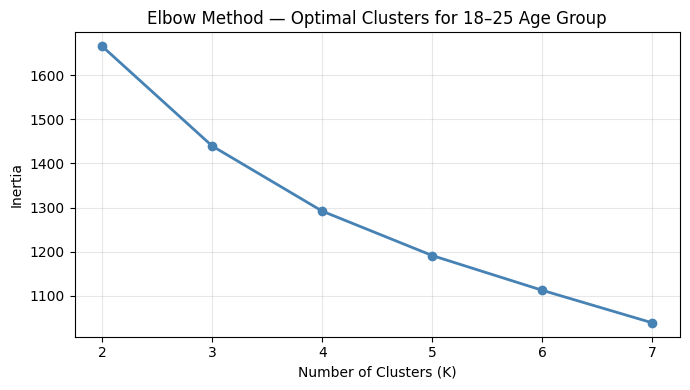

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertias, marker='o', color='steelblue', linewidth=2)
plt.title("Elbow Method — Optimal Clusters for 18–25 Age Group")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

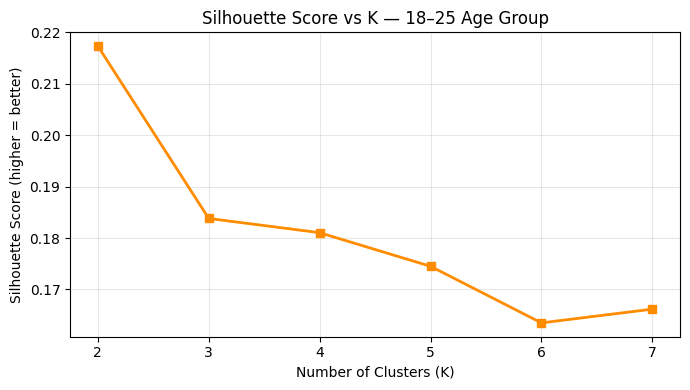

Best K by Silhouette Score: 2


In [ ]:
from sklearn.metrics import silhouette_score

sil_scores = []
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(7, 4))
plt.plot(k_range, sil_scores, marker='s', color='darkorange', linewidth=2)
plt.title("Silhouette Score vs K — 18–25 Age Group")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score (higher = better)")
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_k = k_range[int(np.argmax(sil_scores))]
print(f"Best K by Silhouette Score: {best_k}")

In [ ]:
# Set best_k based on elbow + silhouette plots above (update if needed)
best_k = 2

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_df['cluster'] = kmeans.fit_predict(X_scaled)

print("Customers per cluster:")
print(cluster_df['cluster'].value_counts().sort_index())

Customers per cluster:
cluster
0    140
1    100
Name: count, dtype: int64


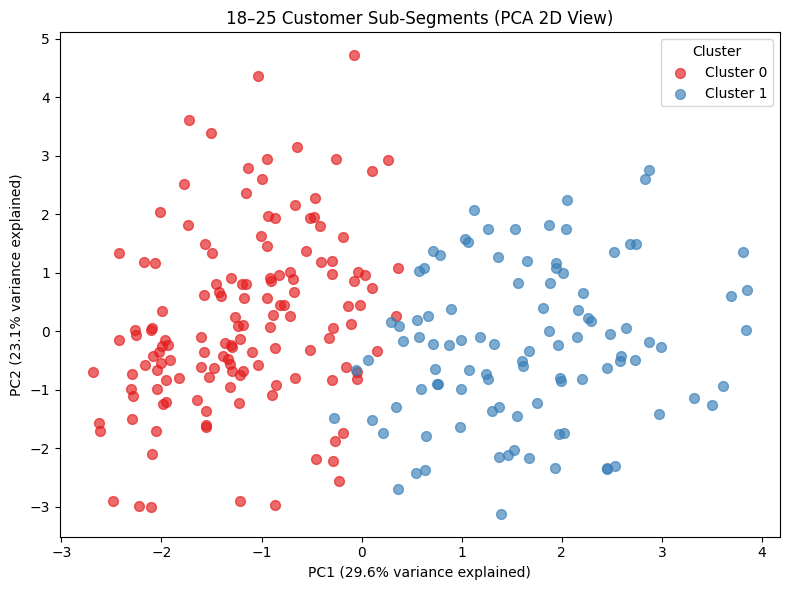

Variance explained by 2 PCs: 52.7%


In [ ]:
from sklearn.decomposition import PCA
import seaborn as sns

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

cluster_df['pca1'] = X_pca[:, 0]
cluster_df['pca2'] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
palette = sns.color_palette("Set1", best_k)
for i in range(best_k):
    mask = cluster_df['cluster'] == i
    plt.scatter(cluster_df.loc[mask, 'pca1'], cluster_df.loc[mask, 'pca2'],
                label=f'Cluster {i}', alpha=0.65, s=50, color=palette[i])

plt.title("18–25 Customer Sub-Segments (PCA 2D View)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance explained)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance explained)")
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

print(f"Variance explained by 2 PCs: {sum(pca.explained_variance_ratio_)*100:.1f}%")

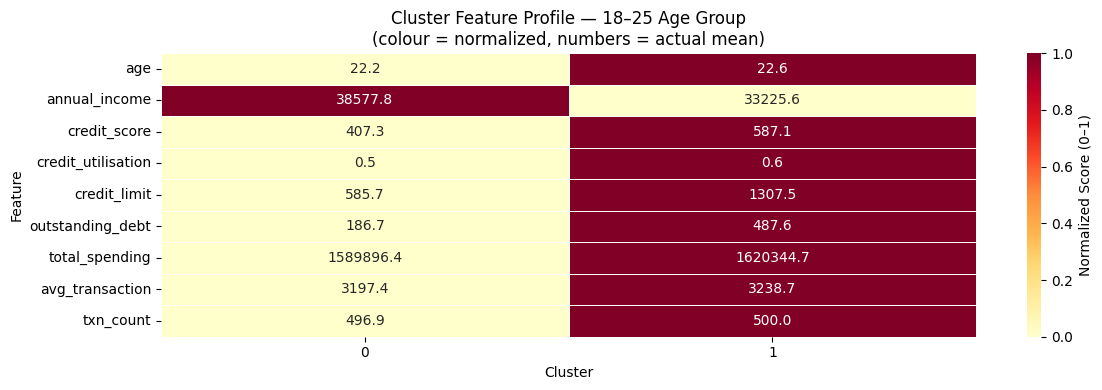

In [ ]:
cluster_profile = cluster_df.groupby('cluster')[features].mean()

# Normalize for heatmap readability
from sklearn.preprocessing import MinMaxScaler
profile_normalized = pd.DataFrame(
    MinMaxScaler().fit_transform(cluster_profile),
    index=cluster_profile.index,
    columns=cluster_profile.columns
)

plt.figure(figsize=(12, 4))
sns.heatmap(profile_normalized.T, annot=cluster_profile.T.round(1),
            fmt=".1f", cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': 'Normalized Score (0–1)'})
plt.title("Cluster Feature Profile — 18–25 Age Group\n(colour = normalized, numbers = actual mean)")
plt.xlabel("Cluster")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

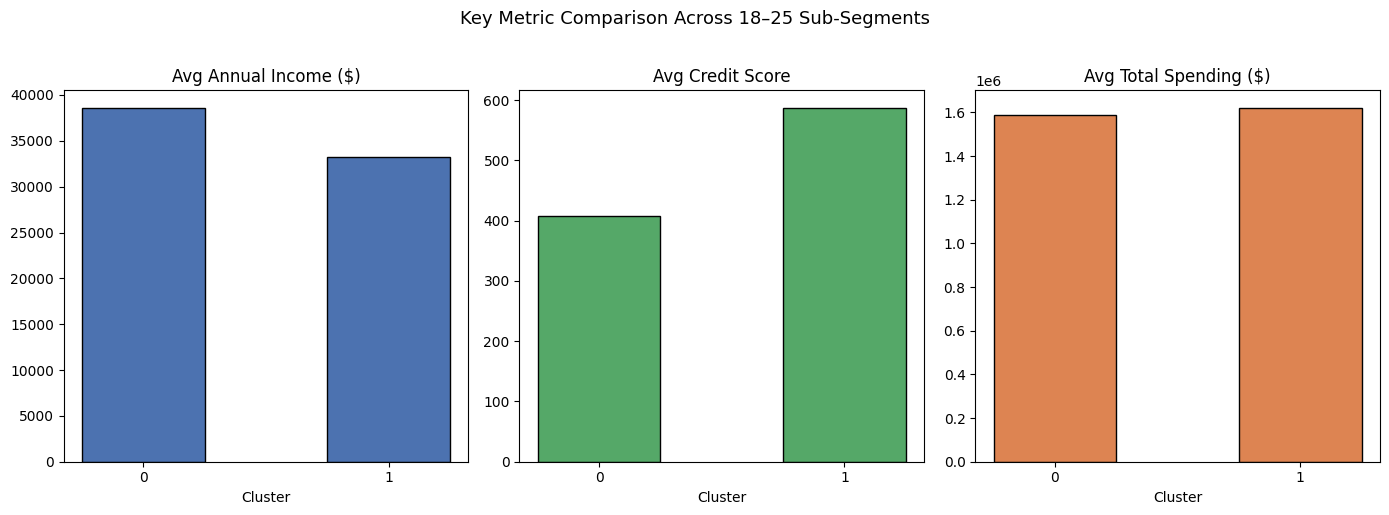

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics    = ['annual_income', 'credit_score', 'total_spending']
titles     = ['Avg Annual Income ($)', 'Avg Credit Score', 'Avg Total Spending ($)']
colors     = ['#4C72B0', '#55A868', '#DD8452']

for ax, metric, title, color in zip(axes, metrics, titles, colors):
    vals = cluster_profile[metric]
    ax.bar(vals.index.astype(str), vals.values, color=color, edgecolor='black', width=0.5)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Cluster")
    ax.tick_params(axis='x', rotation=0)

plt.suptitle("Key Metric Comparison Across 18–25 Sub-Segments", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
print("=" * 60)
print("  CUSTOMER SEGMENT PROFILES — 18 to 25 Age Group")
print("=" * 60)

for i in sorted(cluster_df['cluster'].unique()):
    subset  = cluster_df[cluster_df['cluster'] == i]
    p       = cluster_profile.loc[i]
    count   = len(subset)

    # Income tier distribution for this cluster
    tier_counts = subset['income_tier'].value_counts()
    tier_pct    = (subset['income_tier'].value_counts(normalize=True) * 100).round(1)
    dominant    = tier_pct.idxmax()

    print(f"""
Cluster {i}  ({count} customers)
  Dominant Income Tier  : {dominant}
  Income Tier Breakdown :  Low={tier_pct.get('Low', 0)}%  |  Medium={tier_pct.get('Medium', 0)}%  |  High={tier_pct.get('High', 0)}%
  Avg Credit Score      : {p['credit_score']:.0f}
  Credit Utilisation    : {p['credit_utilisation']:.2f}
  Avg Total Spending    : ${p['total_spending']:,.0f}
  Avg Txn Amount        : ${p['avg_transaction']:,.0f}
  Avg Txn Count         : {p['txn_count']:.0f}
""")

  CUSTOMER SEGMENT PROFILES — 18 to 25 Age Group

Cluster 0  (140 customers)
  Dominant Income Tier  : Medium
  Income Tier Breakdown :  Low=22.1%  |  Medium=49.3%  |  High=28.6%
  Avg Credit Score      : 407
  Credit Utilisation    : 0.48
  Avg Total Spending    : $1,589,896
  Avg Txn Amount        : $3,197
  Avg Txn Count         : 497


Cluster 1  (100 customers)
  Dominant Income Tier  : Medium
  Income Tier Breakdown :  Low=30.0%  |  Medium=51.0%  |  High=19.0%
  Avg Credit Score      : 587
  Credit Utilisation    : 0.56
  Avg Total Spending    : $1,620,345
  Avg Txn Amount        : $3,239
  Avg Txn Count         : 500

